![](img/logo_ucm.jpg)

# MLflow Models

MLflow Models es el componente central que maneja los diferentes **flavors** de modelos que son compatibles en MLflow e intermedia la implementación en diferentes entornos de ejecución. Este módulo gestiona el formato, la biblioteca y la aplicación de estándares en la plataforma.

`````{admonition} Entorno
:class: info
El principal objetivo del empaquetado de modelos en MLflow es desacoplar el modelo de su entorno de ejecución, facilitando su portabilidad y reutilización. Una buena analogía es pensar en un modelo de MLflow como el equivalente a un Dockerfile, pero para modelos de machine learning: define los metadatos y la estructura necesarios para que distintas herramientas de despliegue puedan interactuar con él de forma estándar y consistente, independientemente del framework o lenguaje utilizado.
`````


Los modelos en MLflow utilizan un enfoque de serialización estructurado que permite encapsular tanto el modelo como su entorno de ejecución. Al persistir un modelo, MLflow genera un artefacto que incluye varios archivos clave: el archivo `MLmodel`, que describe el formato del modelo y cómo debe cargarse; el archivo `conda.yaml`, que especifica las dependencias necesarias para reproducir el entorno original; y el archivo `model.pkl`, que contiene el modelo serializado, típicamente en formato pickle en el caso de modelos entrenados con `scikit-learn`. Este sistema asegura la reproducibilidad del modelo y facilita su despliegue en diferentes entornos de forma consistente.



```{figure} img/mlflow/mlflow_model_files.png
---
name: model files
align: center
---
Model files.
```


## Log  y Load Model

El método `mlflow.sklearn.log_model()` se encarga de persistir el modelo después del entrenamiento. Si tenemos el _autolog_ activado, este trabajo se haría automáticamente. 

Esto produce que un modelo almacene el artefacto. Por tanto, es muy sencillo que después podamos recuperar el modelo con toda la meta información que monitoriza MLflow. Por defecto, ya tendríamos el fichero _pickle_. Así pues, para recupera un modelo podemos utilizar el comando `mlflow.sklearn.load_model()`.

`````{admonition} Flavors diferentes
:class: warning
Cada flavor tiene su propio *load_model* y *log_model*. Por ejemplo, *mlflow.tensorflow.log_model()*, *mlflow.keras.load_model()*, etc.
`````

## Pyfunc models: creando modelos personalizados

MLflow Models te proporciona la capacidad de desplegar tus modelos en un entorno nativo de la biblioteca de tu modelo o en un entorno genérico e interoperable de MLflow llamado **Pyfunc**. Esta función es compatible con cualquier entorno que soporte Python, proporcionando flexibilidad al implementador del modelo sobre la mejor manera de ejecutar el modelo una vez registrado en MLflow.

Podemos profundizar en el siguiente fragmento de código y el modelo personalizado `RandomPredictor`. Mientras proporciones una clase con una interfaz que tenga los métodos fit y predict, puedes tener tu propio modelo personalizado de MLflow:

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
import mlflow
import pandas as pd
import numpy as np

class RandomPredictor(mlflow.pyfunc.PythonModel):
    def __init__(self):
        pass
    
    def fit(self):
        pass
    
    def predict(self, context, model_input: pd.DataFrame):
        return model_input.apply(lambda column: np.random.randint(0,1))

En la _class_ anterior, utilizamos una variable aleatoria en el método _predict_. Es un ejemplo didáctico, sin utilidad práctica pero que ejemplifica que si extendemos la clase **_mlflow.pyfunc.PythonModel_** podremos crear nuestros propios modelos siempre y cuando mantengamos la estructura estándar incluyendo los métodos ___init___, _fit_ y _predict_. De lo contrario, tendremos un error en la ejecución.


`````{admonition} Pyfunc class
:class: important
Podemos crear nuestros propios modelos fuera de los listados en _flavors_. Para ello, tenemos que crear una **pyfunc class** con tres funciones: *init*, *fit* y *predict*.
`````

`````{admonition} Log y load pyfunc models
:class: tip
Aquí tenemos *mlflow.pyfunc.log_model()* y *mlflow.pyfunc.load_model()*.
`````

## Signatures y Schemas

Una característica importante de MLflow es proporcionar una abstracción para los esquemas de entrada y salida de los modelos y la capacidad de validar los datos del modelo durante la predicción y el entrenamiento. 

MLflow arroja un error si tu entrada no coincide con el esquema y la firma del modelo durante la predicción. Veamos un ejemplo esta vez con el clásico problema de detección de dígitos. 

In [5]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=False)

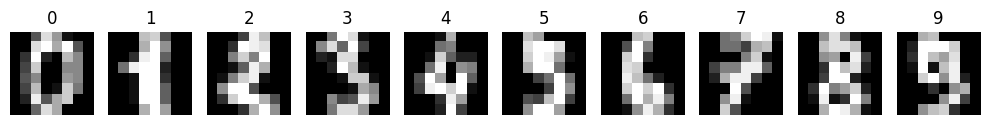

In [6]:
import matplotlib.pyplot as plt

images = digits.images 
labels = digits.target

plt.figure(figsize=(10, 2))
for index in range(10):
    plt.subplot(1, 10, index + 1)
    plt.imshow(images[index], cmap='gray')
    plt.title(str(labels[index]), fontsize=12)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
from sklearn.svm import SVC

model = SVC(gamma=0.001)

In [8]:
mlflow.sklearn.autolog()
with mlflow.start_run():
    model.fit(X_train, y_train)

El archivo MLmodel contiene la firma (_signature_) en JSON de los archivos de entrada y salida. s



```{figure} img/mlflow/models1.png
---
name: models1
align: left
---
Model Signature
```

> 

Volviendo al ejemplo customizado con __pyfunc__, no podremos inferir la firmar automáticamente, por lo que podemos proporcionar la firma al registrar el modelo mediante el método `infer_signature`. Una ventaja importante de que las firmas se registren junto al modelo es que pueden servir como documentación y metadatos para el modelo.

In [10]:
from mlflow.models.signature import infer_signature

class RandomPredictor(mlflow.pyfunc.PythonModel):
    def __init__(self):
        pass
    
    def fit(self):
        pass
    
    def predict(self, context, model_input: pd.DataFrame):
        return model_input.apply(lambda column: np.random.randint(0,1))

model = RandomPredictor()
X_train = pd.DataFrame(np.random.rand(100,3))

with mlflow.start_run(run_name="pyfunc_trial"):

    signature = infer_signature(X_train, model.predict(None, X_train))
    
    mlflow.pyfunc.log_model("RandomPredictor", python_model=model, signature=signature)
    
    # log_metrics, log_params, etc...